# Model Evaluation under Covariate Shift (Domain Adaptation)

In this notebook, we simulate a Linear Covariate Shift using a synthetic `Gaussian Blobs` dataset.
We generate two distinct domains where the target data undergoes an affine transformation (linear shift and scaling):
* **Source Domain (ID):** Standard well-separated Gaussian clusters ($N=500$).
* **Target Domain (OOD):** Shifted and scaled version of the same clusters ($N=500$).

We will evaluate multiple models (Linear, Tree-based, Neural Network, and TabPFN) to observe how their decision boundaries extrapolate into unseen data, and finally test if a linear alignment method (**CORAL**) can mitigate the shift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from scipy.linalg import fractional_matrix_power
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier 
import os
import tabpfn_client # Uncomment if needed

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Generation: Toy Example (Blobs) for CORAL Sanity Check
# ==========================================
# A. Generate Source Domain (Two distinct Gaussian blobs)
X_source_std, y_source_std = make_blobs(n_samples=500, centers=[[-2, -2], [2, 2]], cluster_std=1.0, random_state=42)

# B. Generate Target Domain (Shifted and Scaled version of the same blobs)
# We apply an Affine Transformation (Linear Shift + Scaling) to test CORAL
X_target_std, y_target_std = make_blobs(n_samples=500, centers=[[-2, -2], [2, 2]], cluster_std=1.0, random_state=42)

# Create a Covariance Shift manually: Scale X by 2, stretch Y, and shift the whole data to the right
transformation_matrix = np.array([[2.0, 0.5], 
                                  [0.5, 1.5]])
X_target_std = np.dot(X_target_std, transformation_matrix)
X_target_std += np.array([4.0, 2.0]) # Shift the data so it's clearly out-of-distribution

# C. Combine to maintain the same variable structure as the Moons dataset
X_base_std = np.vstack((X_source_std, X_target_std))
y_base_std = np.hstack((y_source_std, y_target_std))

# Create masks just to keep compatibility with plotting code (though we already split it)
# We mark the first 500 as Source, and the next 500 as Target
source_mask = np.zeros(1000, dtype=bool)
source_mask[:500] = True
target_mask = ~source_mask

# (Variables X_source_std, y_source_std, X_target_std, y_target_std are already defined correctly above)

# ==========================================
# 2. General Evaluation Function
# ==========================================
def train_and_eval(model, X_train, y_train, X_test, y_test):
    """Trains the model and returns accuracies for both source and target."""
    model.fit(X_train, y_train)
    acc_src = accuracy_score(y_train, model.predict(X_train))
    acc_tgt = accuracy_score(y_test, model.predict(X_test))
    return acc_src, acc_tgt

### Visualizing the Covariate Shift

We first visualize the spatial distribution of the data to illustrate the simulated Domain Shift.

In the plot below, we visualize the entire dataset across both domains:
* The circles represent our **Source Domain**. This is the only environment our models will see during training.
* The triangles represent our **Target Domain** (OOD), which has been shifted and stretched.
* Because the shift is linear, standard decision boundaries learned on the Source domain will misclassify Target samples unless the distribution discrepancy is corrected.

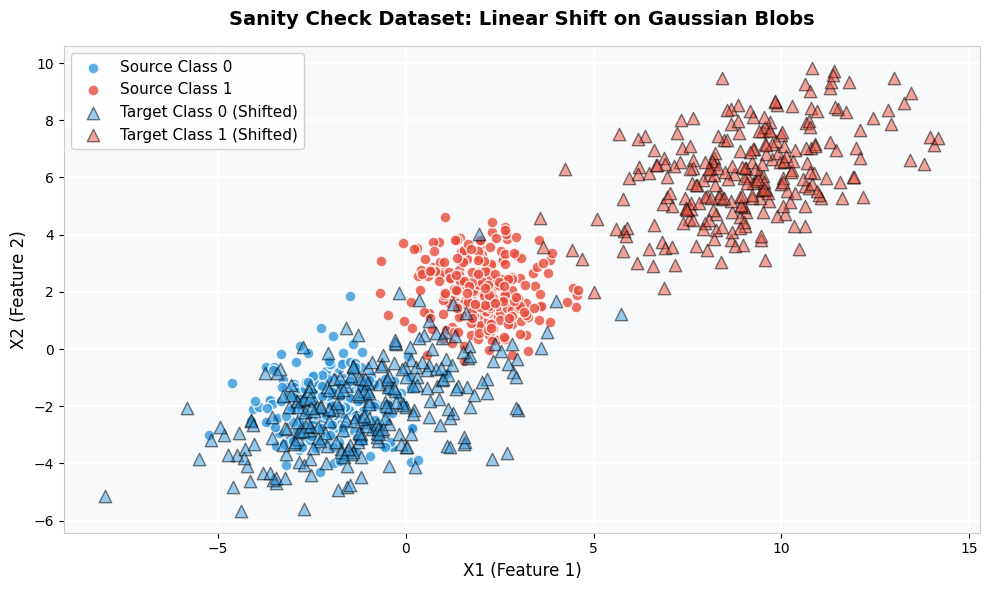

In [2]:
# ==========================================
# 3. Visualizing the Data & The Domain Split
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# Scatter Source (Circles)
ax.scatter(X_source_std[y_source_std==0, 0], X_source_std[y_source_std==0, 1], 
           c=color_blue, marker='o', edgecolors='white', s=60, alpha=0.8, label='Source Class 0')
ax.scatter(X_source_std[y_source_std==1, 0], X_source_std[y_source_std==1, 1], 
           c=color_red, marker='o', edgecolors='white', s=60, alpha=0.8, label='Source Class 1')

# Scatter Target (Triangles) to show the Shift
ax.scatter(X_target_std[y_target_std==0, 0], X_target_std[y_target_std==0, 1], 
           c=color_blue, marker='^', edgecolors='black', s=80, alpha=0.5, label='Target Class 0 (Shifted)')
ax.scatter(X_target_std[y_target_std==1, 0], X_target_std[y_target_std==1, 1], 
           c=color_red, marker='^', edgecolors='black', s=80, alpha=0.5, label='Target Class 1 (Shifted)')


# Aesthetics
ax.set_title("Sanity Check Dataset: Linear Shift on Gaussian Blobs", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("X1 (Feature 1)", fontsize=12)
ax.set_ylabel("X2 (Feature 2)", fontsize=12)
ax.set_facecolor('#f8f9fa')
ax.grid(True, color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)

# Clean borders
for spine in ax.spines.values():
    spine.set_color('#cccccc')

ax.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

## Base Models Evaluation

We will train standard classifiers exclusively on the Source Domain and test their generalization on the Target Domain.

### Linear Baselines: Standard Logistic Regression

We begin our evaluation with a standard linear model. Logistic Regression provides a highly interpretable baseline, learning a simple linear decision boundary. 

**The Importance of Feature Scaling:**
While our current dataset is low-dimensional (2D), we apply `StandardScaler` to normalize our features ($mean=0$, $variance=1$). This is a machine learning best practice that ensures stable and fast mathematical convergence for the solver. Furthermore, it sets up a robust pipeline for when we later introduce high-dimensional data and scale-sensitive regularization techniques.

In [3]:
# ==========================================
# 1. Feature Scaling
# ==========================================
# Fit scaler ONLY on Source domain to prevent data leakage
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source_std)
X_target_scaled = scaler.transform(X_target_std)

# ==========================================
# 2. Model Training
# ==========================================
lr_model = LogisticRegression(random_state=42)
lr_src_acc, lr_tgt_acc = train_and_eval(lr_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"Logistic Regression Accuracy on Source Data: {lr_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"Logistic Regression Accuracy on Target Data: {lr_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
Logistic Regression Accuracy on Source Data: 0.996

--- Target Domain (OOD) ---
Logistic Regression Accuracy on Target Data: 0.914



### Tree-Based Ensemble: XGBoost

Next, we evaluate XGBoost, a powerful gradient boosting framework. Unlike linear models, tree-based models learn decision boundaries through orthogonal splits (axis-parallel cuts). We expect a step-like boundary that fits the Source domain well but may struggle to generalize smoothly to the shifted Target coordinates without adaptation.

In [4]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_src_acc, xgb_tgt_acc = train_and_eval(xgb_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"XGBoost Accuracy on Source Data: {xgb_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"XGBoost Accuracy on Target Data: {xgb_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
XGBoost Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
XGBoost Accuracy on Target Data: 0.940



### Neural Networks: Multi-Layer Perceptron (MLP)

We evaluate the Multi-Layer Perceptron as our deep learning baseline. As a universal function approximator, an MLP with hidden layers can learn flexible, non-linear representations. 

**The Extrapolation Challenge:** We expect the MLP to achieve high accuracy on the Source domain (ID). However, standard neural networks can be sensitive to spatial distribution shifts. When presented with the Target domain (OOD) where the coordinates are shifted and scaled, the MLP's learned boundary may fail, highlighting the challenge of Covariate Shift.

In [5]:
# Initialize and train MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

mlp_src_acc, mlp_tgt_acc = train_and_eval(mlp_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"MLP Accuracy on Source Data: {mlp_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"MLP Accuracy on Target Data: {mlp_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
MLP Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
MLP Accuracy on Target Data: 0.924



### Foundation Models: TabPFN

Finally, we test TabPFN, a Prior-Data Fitted Network that performs in-context learning for tabular data without traditional weight optimization. It relies on a Transformer architecture pre-trained on synthetic datasets. We test how an attention-based foundation model handles Covariate Shift.

**Note on TabPFN Usage:**
Recent updates to the `tabpfn` library require a free API token to access the foundation model. To run the cell below locally:
1. Open https://ux.priorlabs.ai in a browser and log in (or register).
2. Accept the license on the Licenses tab.
3. Copy your API token from the account page.
4. Replace `"YOUR_API_KEY_HERE"` in the code below with your actual token.

In [ ]:
# ==========================================
# 1. TabPFN License & Initialization
# ==========================================
TABPFN_TOKEN = "YOUR_API_KEY_HERE" 

# Applying the token to the environment and the client
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
tabpfn_client.set_access_token(TABPFN_TOKEN)

# Initialize TabPFN
tabpfn_model = TabPFNClassifier(device="cpu") 

# ==========================================
# 2. Model Training & Evaluation
# ==========================================
tabpfn_src_acc, tabpfn_tgt_acc = train_and_eval(tabpfn_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"TabPFN Accuracy on Source Data: {tabpfn_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"TabPFN Accuracy on Target Data: {tabpfn_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
TabPFN Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
TabPFN Accuracy on Target Data: 0.926



### Decision Boundary Comparison under Covariate Shift

To evaluate OOD extrapolation, we visualize the learned decision boundaries over the entire dataset space. 
This grid allows us to visually compare the linear rigidity of Logistic Regression, the orthogonal splits of XGBoost, and the flexible curves of the MLP and TabPFN across both the ID and OOD distributions.

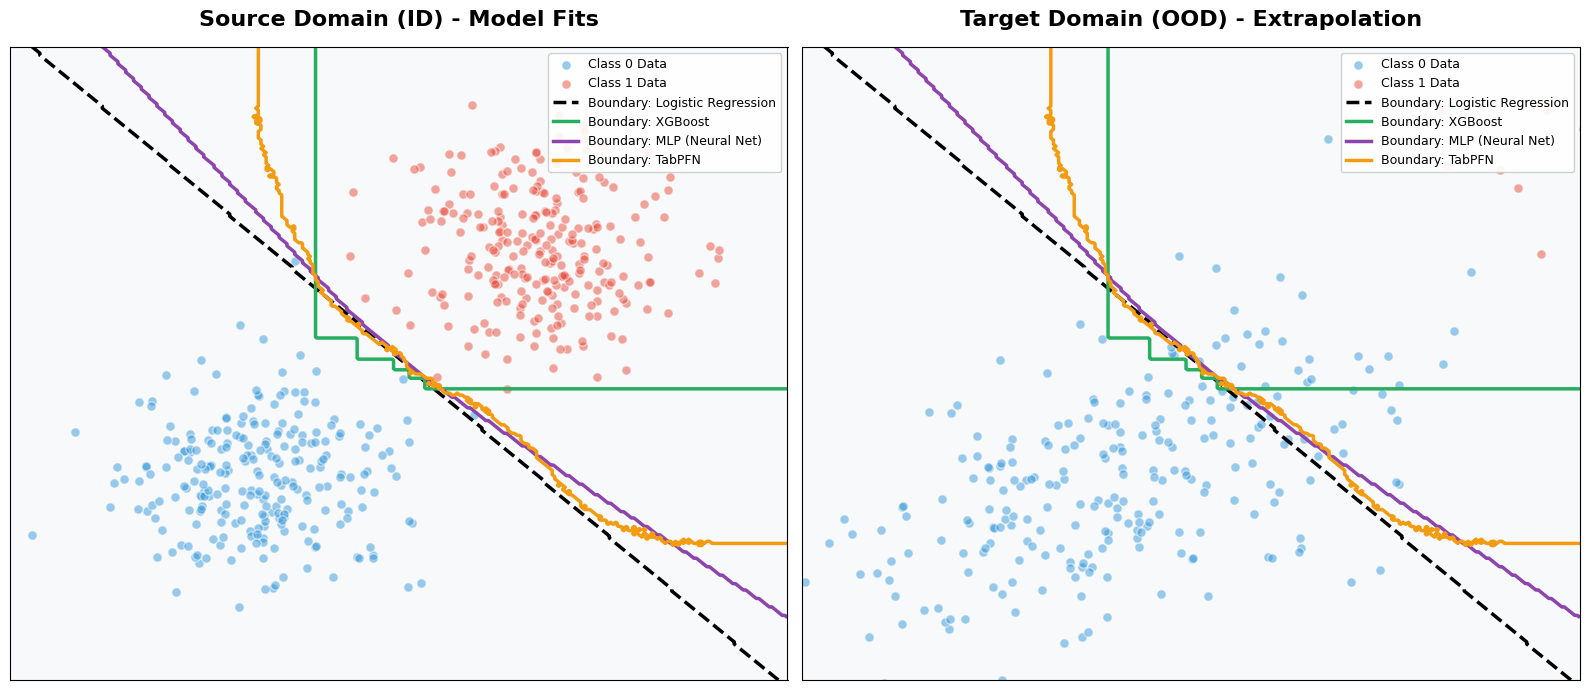

In [7]:
# Create a dictionary of our trained models
trained_models = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model,
    'MLP (Neural Net)': mlp_model,
    'TabPFN': tabpfn_model
}

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(16, 7))

color_class_0 = '#3498db'
color_class_1 = '#e74c3c'

# Define distinct colors and styles for each model's boundary line
model_styles = {
    'Logistic Regression': {'color': 'black', 'style': '--'},
    'XGBoost': {'color': '#27ae60', 'style': '-'},      # Green
    'MLP (Neural Net)': {'color': '#8e44ad', 'style': '-'}, # Purple
    'TabPFN': {'color': '#f39c12', 'style': '-'}        # Orange
}

def plot_overlay_boundaries(ax, X_data, y_data, title):
    # Set grid limits based on scaled data
    x_min, x_max = -2.5, 2.5
    y_min, y_max = -2.5, 2.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    
    # Scatter the actual data points
    ax.scatter(X_data[y_data==0, 0], X_data[y_data==0, 1], c=color_class_0, edgecolors='white', alpha=0.5, s=45, label='Class 0 Data')
    ax.scatter(X_data[y_data==1, 0], X_data[y_data==1, 1], c=color_class_1, edgecolors='white', alpha=0.5, s=45, label='Class 1 Data')
    
    # Loop through models and draw ONLY their decision boundaries (Z = 0.5)
    for name, model in trained_models.items():
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        # levels=[0.5] draws the line exactly where the model switches from predicting 0 to 1
        ax.contour(xx, yy, Z, levels=[0.5], colors=[model_styles[name]['color']], 
                   linestyles=model_styles[name]['style'], linewidths=2.5)
        # We use a dummy plot for the legend to represent the line
        ax.plot([], [], color=model_styles[name]['color'], linestyle=model_styles[name]['style'], linewidth=2.5, label=f'Boundary: {name}')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#f8f9fa') # Light gray background for contrast
    
    # Organize the legend
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Plot Source Only
plot_overlay_boundaries(ax_s, X_source_scaled, y_source_std, "Source Domain (ID) - Model Fits")

# Plot Target Only
plot_overlay_boundaries(ax_t, X_target_scaled, y_target_std, "Target Domain (OOD) - Extrapolation")

plt.tight_layout()
plt.show()

### Systematic Comparison: Model Generalization under Covariate Shift

Visualizing the accuracy side-by-side reveals the generalization capabilities across domains:

* **The Source Domain (ID):** All models perform exceptionally well, successfully learning the underlying separable clusters of the training distribution.
* **The Target Domain (OOD):** Due to the affine transformation (scaling and spatial shift), models trained solely on the Source coordinates experience a drop in accuracy on the Target domain—demonstrating that even on linearly separable tasks, Covariate Shift harms generalization without domain adaptation.

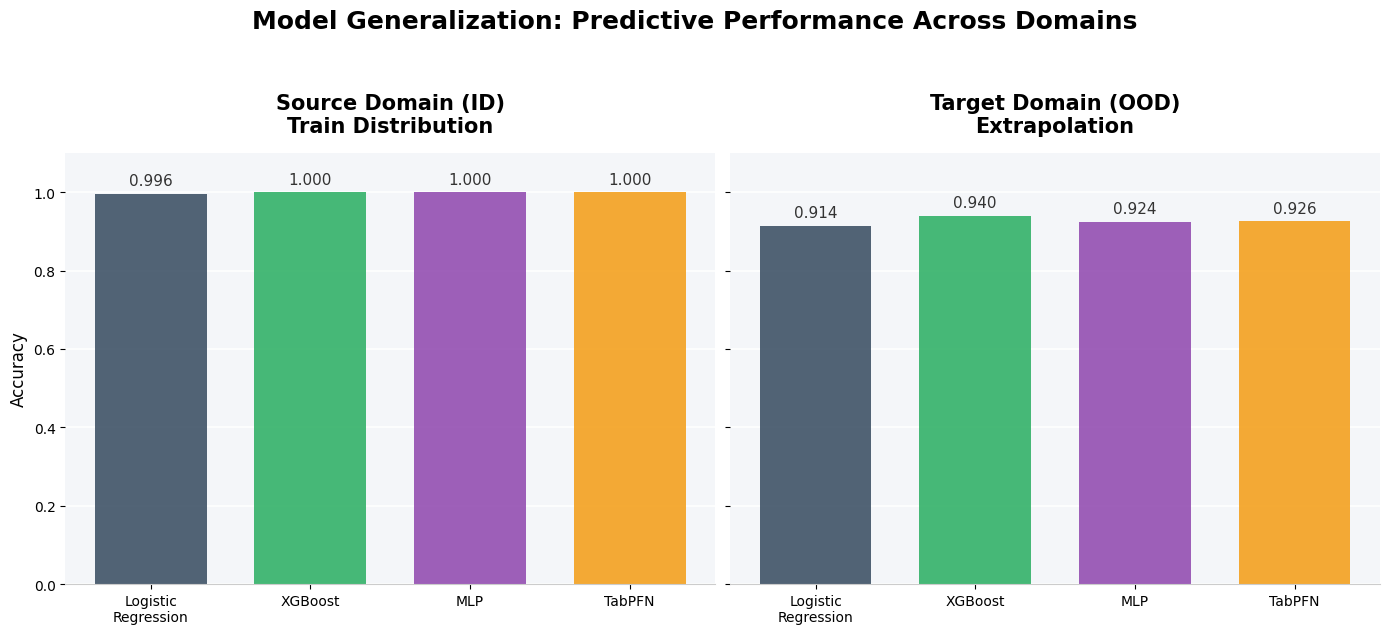

In [8]:
# ==========================================
# 6. Final Performance Comparison Bar Chart
# ==========================================
# Aggregate the accuracies we computed earlier
model_names = ['Logistic\nRegression', 'XGBoost', 'MLP', 'TabPFN']
src_accuracies = [lr_src_acc, xgb_src_acc, mlp_src_acc, tabpfn_src_acc]
tgt_accuracies = [lr_tgt_acc, xgb_tgt_acc, mlp_tgt_acc, tabpfn_tgt_acc]

# We use the exact same color palette defined in the overlay plot
bar_colors = ['#34495e', '#27ae60', '#8e44ad', '#f39c12'] 
# (Dark Slate for LR, Green for XGB, Purple for MLP, Orange for TabPFN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Plot Source Domain ---
bars_src = ax1.bar(model_names, src_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax1.set_title('Source Domain (ID)\nTrain Distribution', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)

# --- Plot Target Domain ---
bars_tgt = ax2.bar(model_names, tgt_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax2.set_title('Target Domain (OOD)\nExtrapolation', fontsize=15, fontweight='bold', pad=15)

# Function to automatically attach text labels above each bar
def attach_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='500', color='#333333')

attach_labels(bars_src, ax1)
attach_labels(bars_tgt, ax2)

# Clean Aesthetics
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.1) # Leave headroom for the text labels
    ax.set_facecolor('#f4f6f9') # Soft gray background like ggplot
    ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_axisbelow(True) # Put grid behind bars
    
    # Remove outer spines for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    # Thicken x-axis line slightly
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')

plt.suptitle("Model Generalization: Predictive Performance Across Domains", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Domain Adaptation: CORAL (Correlation Alignment)

To address the Covariate Shift, we apply the **CORAL** algorithm. CORAL attempts to align the second-order statistics (covariance matrices) of the Source and Target distributions using a linear transformation (scaling, shifting, and rotating).

Before evaluating the models, let's visualize what CORAL physically does to our data. We will compute the transformation and plot the original Source, the Target, and the newly Aligned Source.

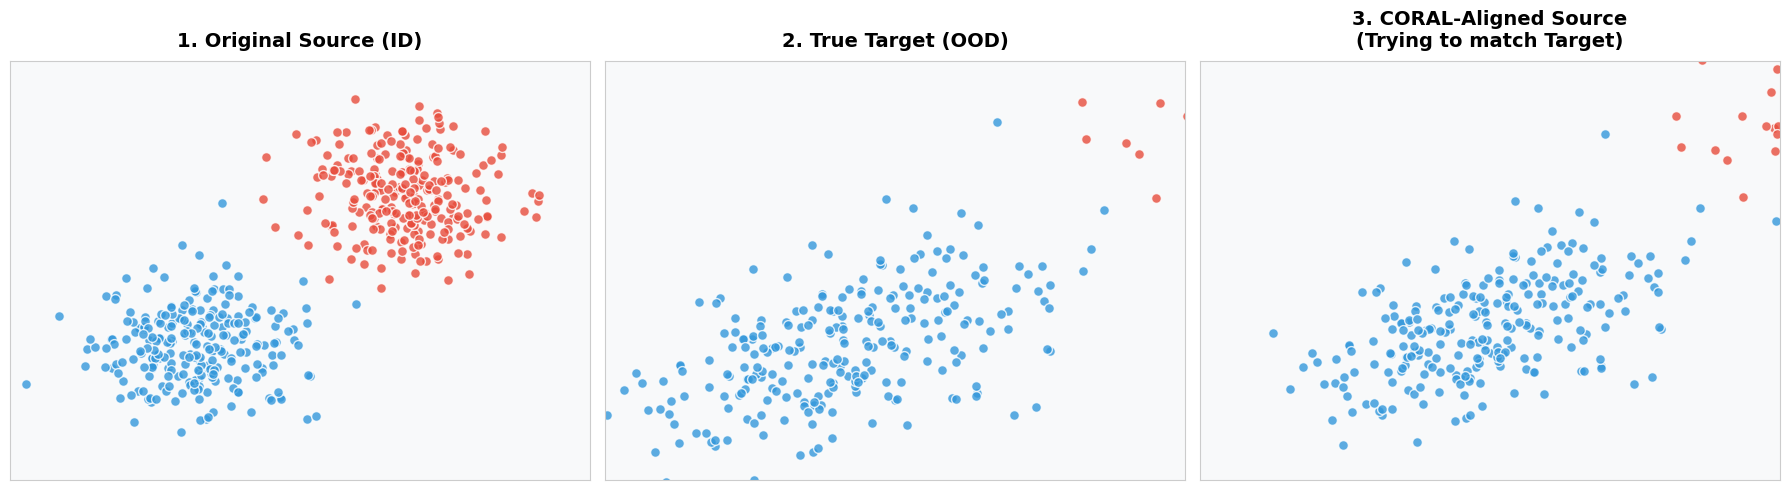

In [9]:
from scipy.linalg import fractional_matrix_power

# ==========================================
# 1. CORAL Algorithm Implementation
# ==========================================
def coral_alignment(X_s, X_t, lambda_reg=1.0):
    d = X_s.shape[1]
    Cs = np.cov(X_s, rowvar=False) + np.eye(d) * lambda_reg
    Ct = np.cov(X_t, rowvar=False) + np.eye(d) * lambda_reg
    
    Cs_inv_sqrt = fractional_matrix_power(Cs, -0.5)
    Ct_sqrt = fractional_matrix_power(Ct, 0.5)
    
    X_s_centered = X_s - np.mean(X_s, axis=0)
    X_s_aligned = X_s_centered @ Cs_inv_sqrt @ Ct_sqrt + np.mean(X_t, axis=0)
    
    return np.real(X_s_aligned)

# Apply CORAL to align scaled Source to scaled Target
X_source_coral = coral_alignment(X_source_scaled, X_target_scaled)

# ==========================================
# 2. Visualize the Transformation
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
color_blue, color_red = '#3498db', '#e74c3c'

def plot_scatter(ax, X, y, title):
    ax.scatter(X[y==0][:, 0], X[y==0][:, 1], c=color_blue, edgecolors='white', s=50, alpha=0.8, label='Class 0')
    ax.scatter(X[y==1][:, 0], X[y==1][:, 1], c=color_red, edgecolors='white', s=50, alpha=0.8, label='Class 1')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('#f8f9fa')
    for spine in ax.spines.values(): spine.set_color('#cccccc')

plot_scatter(ax1, X_source_scaled, y_source_std, "1. Original Source (ID)")
plot_scatter(ax2, X_target_scaled, y_target_std, "2. True Target (OOD)")
plot_scatter(ax3, X_source_coral, y_source_std, "3. CORAL-Aligned Source\n(Trying to match Target)")

plt.tight_layout()
plt.show()

**Observation on the CORAL Transformation:**
Looking at the third plot, we can see how CORAL successfully shifts and rescales the Source domain to match the statistical profile of the Target domain. 

### Re-Evaluating Models Post-Alignment

Now that our Source data is aligned with the Target, we retrain all our models on this new `CORAL-Aligned Source` space and test them again on the `Target` domain. 

**Hypothesis:** Because the underlying domain shift in our synthetic dataset was created using a linear affine transformation, aligning the covariance matrices via CORAL should theoretically resolve the discrepancy. We hypothesize that after applying CORAL, all classifiers will achieve a substantial performance jump, approaching optimal generalization.

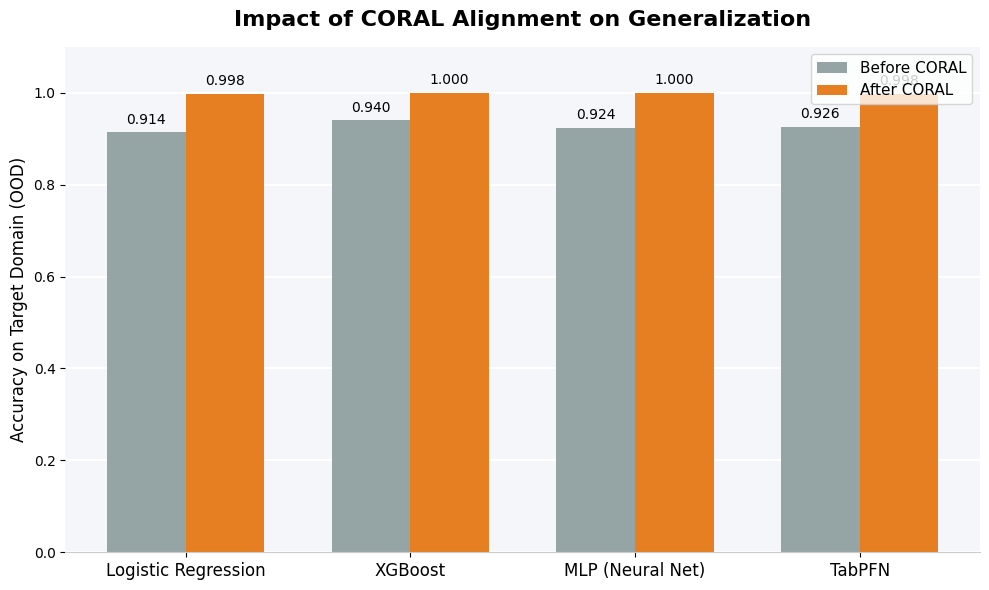

In [10]:
# ==========================================
# 3. Retrain Models & Collect Results
# ==========================================
# Assuming `trained_models` dict from earlier is still in memory
# Example: trained_models = {'Logistic Regression': lr_model, 'XGBoost': xgb_model, ...}

results_before = []
results_after = []
model_names_list = list(trained_models.keys())

for name, model in trained_models.items():
    # 1. Performance BEFORE CORAL (Train on Standard Source)
    model.fit(X_source_scaled, y_source_std)
    acc_before = accuracy_score(y_target_std, model.predict(X_target_scaled))
    results_before.append(acc_before)
    
    # 2. Performance AFTER CORAL (Train on Aligned Source)
    model.fit(X_source_coral, y_source_std)
    acc_after = accuracy_score(y_target_std, model.predict(X_target_scaled))
    results_after.append(acc_after)

# ==========================================
# 4. Plot Grouped Bar Chart
# ==========================================
x = np.arange(len(model_names_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Use distinct colors for Before/After
rects1 = ax.bar(x - width/2, results_before, width, label='Before CORAL', color='#95a5a6')
rects2 = ax.bar(x + width/2, results_after, width, label='After CORAL', color='#e67e22')

ax.set_ylabel('Accuracy on Target Domain (OOD)', fontsize=12)
ax.set_title('Impact of CORAL Alignment on Generalization', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names_list, fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.1)

# Clean aesthetics
ax.set_facecolor('#f4f6f9')
ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('#cccccc')

# Function to attach text labels
def attach_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='500')

attach_labels(rects1)
attach_labels(rects2)

plt.tight_layout()
plt.show()

## High-Dimensional Data Generalization ($P \gg N$)

In the real world, especially in domains like bioinformatics, tabular data is rarely confined to a few clean variables. It is often extremely high-dimensional, characterized by having significantly more features ($P$) than samples ($N$). A key challenge in this regime is that the vast majority of these features are irrelevant noise.

**The Simulation Strategy:**
To simulate this environment, we take our 2D informative `Gaussian Blobs` dataset ($N=500$) and append 1998 pure noise features (drawn from a Gaussian distribution). We apply the exact same Covariate Shift across domains. 

**The Dual Challenge:**
The models must now tackle two severe problems simultaneously:
1. **Feature Selection:** Avoiding catastrophic overfitting to the 1998 noise dimensions (The Curse of Dimensionality).
2. **Domain Adaptation:** Extrapolating the learned boundary to the unseen Target domain under high-dimensional noise.

**Terminology:**
* **$N$ (Number of Samples):** The number of data points. Here, $N=500$ (250 Source, 250 Target).
* **$P$ (Number of Features):** The total number of dimensions. In this section, $P=2000$ (2 true informative dimensions + 1998 nuisance dimensions).

In [11]:
# ==========================================
# 1. High-Dimensional Data Generation (Blobs + Noise)
# ==========================================
N_SAMPLES = 500
P_DIMENSIONS = 2000  # 2 informative features + 1998 noise features

# A. Generate the base 2D informative features (Source & Target Blobs)
X_source_2d, y_source_bio = make_blobs(n_samples=N_SAMPLES // 2, centers=[[-2, -2], [2, 2]], cluster_std=1.0, random_state=42)
X_target_2d, y_target_bio = make_blobs(n_samples=N_SAMPLES // 2, centers=[[-2, -2], [2, 2]], cluster_std=1.0, random_state=42)

# Apply the linear shift + scaling (Covariate Shift) to Target
transformation_matrix = np.array([[2.0, 0.5], 
                                  [0.5, 1.5]])
X_target_2d = np.dot(X_target_2d, transformation_matrix)
X_target_2d += np.array([4.0, 2.0])

# Combine Source and Target 2D informative features
X_base_2d = np.vstack((X_source_2d, X_target_2d))
y_base_bio = np.hstack((y_source_bio, y_target_bio))

# B. Generate nuisance features (pure Gaussian noise)
np.random.seed(42)  # For reproducibility
noise_features = np.random.normal(loc=0, scale=1, size=(N_SAMPLES, P_DIMENSIONS - 2))

# C. Concatenate informative features with noise features to create the final dataset
X_base_bio = np.hstack((X_base_2d, noise_features))

print(f"Original 2D Shape: {X_base_2d.shape}")
print(f"High-Dimensional Shape: {X_base_bio.shape}")

# ==========================================
# 2. Domain Split
# ==========================================
# We already generated the first half as Source and second half as Target
source_mask_bio = np.zeros(N_SAMPLES, dtype=bool)
source_mask_bio[: N_SAMPLES // 2] = True
target_mask_bio = ~source_mask_bio

X_source_bio, y_source_bio = X_base_bio[source_mask_bio], y_base_bio[source_mask_bio]
X_target_bio, y_target_bio = X_base_bio[target_mask_bio], y_base_bio[target_mask_bio]

print(f"\nSource Domain Samples: {len(X_source_bio)}")
print(f"Target Domain Samples: {len(X_target_bio)}")

# ==========================================
# 3. Feature Scaling (Critical for High-Dim and Regularization)
# ==========================================
scaler_bio = StandardScaler()
X_source_bio_scaled = scaler_bio.fit_transform(X_source_bio)
X_target_bio_scaled = scaler_bio.transform(X_target_bio)

Original 2D Shape: (500, 2)
High-Dimensional Shape: (500, 2000)

Source Domain Samples: 250
Target Domain Samples: 250


### Linear Baselines: Standard Logistic Regression vs. LASSO

In high-dimensional spaces where most features are noise, a standard linear model often struggles. We compare standard Logistic Regression (L2 regularization by default) against **LASSO (L1 regularization)**. LASSO is particularly useful here as it acts as an embedded feature selector, driving the weights of irrelevant features exactly to zero.

In [12]:
# Standard Logistic Regression
lr_model_bio = LogisticRegression(random_state=42)
lr_src_acc_bio, lr_tgt_acc_bio = train_and_eval(lr_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

# LASSO Logistic Regression (L1 penalty)
lasso_model_bio = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lasso_src_acc_bio, lasso_tgt_acc_bio = train_and_eval(lasso_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

# Count retained features for LASSO
retained_features = np.sum(lasso_model_bio.coef_ != 0)
total_features = X_source_bio_scaled.shape[1]

print("--- Source Domain (ID) ---")
print(f"Logistic Regression Accuracy on Source Data: {lr_src_acc_bio:.3f}")
print(f"LASSO (L1) Accuracy on Source Data:          {lasso_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"Logistic Regression Accuracy on Target Data: {lr_tgt_acc_bio:.3f}")
print(f"LASSO (L1) Accuracy on Target Data:          {lasso_tgt_acc_bio:.3f}\n")

print(f"* Note: LASSO retained {retained_features} out of {total_features} features.")

--- Source Domain (ID) ---
Logistic Regression Accuracy on Source Data: 1.000
LASSO (L1) Accuracy on Source Data:          1.000

--- Target Domain (OOD) ---
Logistic Regression Accuracy on Target Data: 0.872
LASSO (L1) Accuracy on Target Data:          0.908

* Note: LASSO retained 23 out of 2000 features.


### Tree-Based Ensemble: XGBoost

Tree-based models generally perform well with uninformative features because they inherently select the most discriminative splits. We expect XGBoost to handle the noise features relatively well during training, but its step-like decision boundaries will still face the fundamental challenge of the non-linear domain shift.

In [13]:
# Initialize and train XGBoost
xgb_model_bio = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_src_acc_bio, xgb_tgt_acc_bio = train_and_eval(xgb_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"XGBoost Accuracy on Source Data: {xgb_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"XGBoost Accuracy on Target Data: {xgb_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
XGBoost Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
XGBoost Accuracy on Target Data: 0.892



### Neural Networks: Multi-Layer Perceptron (MLP)

Standard MLPs lack built-in feature selection. In high-dimensional spaces with low sample sizes, they are highly prone to memorizing the noise features rather than learning the true underlying signal. We anticipate the MLP will show a significant performance drop compared to its performance on the 2D dataset.

In [14]:
# Initialize and train MLP
mlp_model_bio = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

mlp_src_acc_bio, mlp_tgt_acc_bio = train_and_eval(mlp_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"MLP Accuracy on Source Data: {mlp_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"MLP Accuracy on Target Data: {mlp_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
MLP Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
MLP Accuracy on Target Data: 0.624



### Foundation Models: TabPFN

We evaluate how TabPFN handles high-dimensional noise. While its attention mechanism might help focus on relevant features, Transformers can also struggle when the noise-to-signal ratio is extreme.

**Note on TabPFN Usage:**
Remember to ensure your API token is active.

In [15]:
# Initialize TabPFN (assuming token is already set in the environment from Part 1)
tabpfn_model_bio = TabPFNClassifier(device="cpu") 

# Train & Evaluate
tabpfn_src_acc_bio, tabpfn_tgt_acc_bio = train_and_eval(tabpfn_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"TabPFN Accuracy on Source Data: {tabpfn_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"TabPFN Accuracy on Target Data: {tabpfn_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
TabPFN Accuracy on Source Data: 0.996

--- Target Domain (OOD) ---
TabPFN Accuracy on Target Data: 0.936



### Systematic Comparison: High-Dimensional Model Generalization

Visualizing the accuracy side-by-side reveals how the dual challenge of Domain Shift and Extreme Dimensionality impacts these models:

* **The Dimensionality Curse:** Unlike the low-dimensional case, standard models without feature selection struggle heavily when flooded with 1998 noise dimensions. LASSO demonstrates the critical importance of L1 regularization in identifying the true signal.
* **The Extrapolation Challenge:** Even when models successfully resist overfitting to the noise features, their OOD performance remains constrained by the unaligned Covariate Shift between the domains.

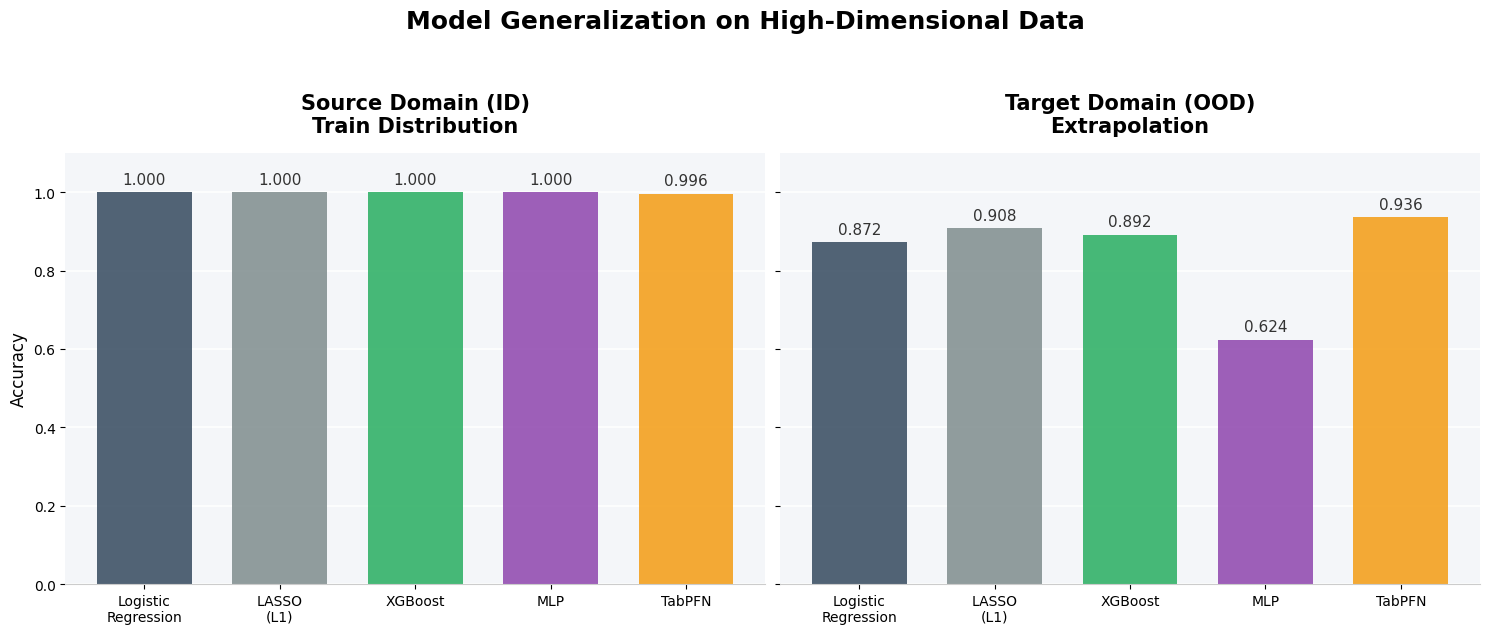

In [17]:
# ==========================================
# Final Performance Comparison Bar Chart (High-Dimensional)
# ==========================================
# Define a fresh function for this specific cell to avoid memory conflicts
def attach_labels_bio(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='500', color='#333333')

# Aggregate the accuracies (Including LASSO this time)
model_names_bio = ['Logistic\nRegression', 'LASSO\n(L1)', 'XGBoost', 'MLP', 'TabPFN']
src_accuracies_bio = [lr_src_acc_bio, lasso_src_acc_bio, xgb_src_acc_bio, mlp_src_acc_bio, tabpfn_src_acc_bio]
tgt_accuracies_bio = [lr_tgt_acc_bio, lasso_tgt_acc_bio, xgb_tgt_acc_bio, mlp_tgt_acc_bio, tabpfn_tgt_acc_bio]

bar_colors_bio = ['#34495e', '#7f8c8d', '#27ae60', '#8e44ad', '#f39c12'] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Plot Source Domain ---
bars_src_bio = ax1.bar(model_names_bio, src_accuracies_bio, color=bar_colors_bio, alpha=0.85, width=0.7)
ax1.set_title('Source Domain (ID)\nTrain Distribution', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)

# --- Plot Target Domain ---
bars_tgt_bio = ax2.bar(model_names_bio, tgt_accuracies_bio, color=bar_colors_bio, alpha=0.85, width=0.7)
ax2.set_title('Target Domain (OOD)\nExtrapolation', fontsize=15, fontweight='bold', pad=15)

# Use the newly defined function
attach_labels_bio(bars_src_bio, ax1)
attach_labels_bio(bars_tgt_bio, ax2)

# Clean Aesthetics
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.1) 
    ax.set_facecolor('#f4f6f9') 
    ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_axisbelow(True) 
    
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')

plt.suptitle("Model Generalization on High-Dimensional Data", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Domain Adaptation in High Dimensions: Evaluating CORAL ($P=2000$)

We now test whether **CORAL** can successfully align the covariance matrices when the feature space is extremely high-dimensional ($P=2000, N=250$). 

**The Regularization Requirement:**
In high-dimensional regimes where $P > N$, empirical sample covariance matrices become singular and non-invertible. The regularized formulation of CORAL ($\lambda = 1.0$) adds the identity matrix to stabilize the covariance inversion ($\hat{C} = C + \lambda I$).

We retrain all five baseline classifiers on the high-dimensional `CORAL-Aligned Source` space and observe whether linear statistics alignment remains effective in the presence of 1,998 nuisance noise features.

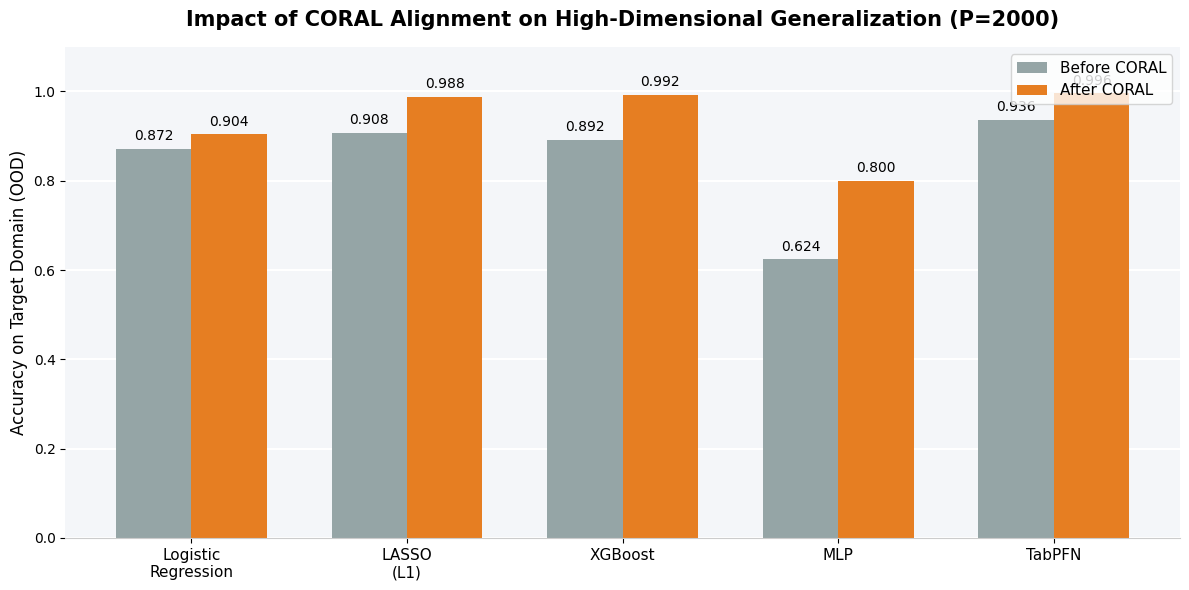

In [18]:
# ==========================================
# 1. Apply CORAL to High-Dimensional Data
# ==========================================
# We use the coral_alignment function defined earlier
# Note: lambda_reg=1.0 is essential here since P (2000) > N (250)
X_source_coral_bio = coral_alignment(X_source_bio_scaled, X_target_bio_scaled, lambda_reg=1.0)

# ==========================================
# 2. Retrain Models & Collect High-Dim Results
# ==========================================
# Create a dictionary of all 5 high-dimensional models (including LASSO)
trained_models_bio = {
    'Logistic\nRegression': lr_model_bio,
    'LASSO\n(L1)': lasso_model_bio,
    'XGBoost': xgb_model_bio,
    'MLP': mlp_model_bio,
    'TabPFN': tabpfn_model_bio
}

results_before_bio = []
results_after_bio = []
model_names_bio_list = list(trained_models_bio.keys())

for name, model in trained_models_bio.items():
    # 1. Performance BEFORE CORAL (Train on Standard High-Dim Source)
    model.fit(X_source_bio_scaled, y_source_bio)
    acc_before = accuracy_score(y_target_bio, model.predict(X_target_bio_scaled))
    results_before_bio.append(acc_before)
    
    # 2. Performance AFTER CORAL (Train on Aligned High-Dim Source)
    model.fit(X_source_coral_bio, y_source_bio)
    acc_after = accuracy_score(y_target_bio, model.predict(X_target_bio_scaled))
    results_after_bio.append(acc_after)

# ==========================================
# 3. Plot Grouped Bar Chart (High-Dimensional)
# ==========================================
x = np.arange(len(model_names_bio_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Use distinct colors for Before/After
rects1_bio = ax.bar(x - width/2, results_before_bio, width, label='Before CORAL', color='#95a5a6')
rects2_bio = ax.bar(x + width/2, results_after_bio, width, label='After CORAL', color='#e67e22')

ax.set_ylabel('Accuracy on Target Domain (OOD)', fontsize=12)
ax.set_title('Impact of CORAL Alignment on High-Dimensional Generalization (P=2000)', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names_bio_list, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.1)

# Clean aesthetics
ax.set_facecolor('#f4f6f9')
ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('#cccccc')

# Function to attach text labels
def attach_labels_coral_bio(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='500')

attach_labels_coral_bio(rects1_bio)
attach_labels_coral_bio(rects2_bio)

plt.tight_layout()
plt.show()